In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [69]:
df = pd.read_csv('dataset_problema2.csv')

In [70]:
x = df.drop(['id', 'Severidade'], axis=1)
y= df['Severidade']


In [71]:
# Separar dados de treinamento de teste
from sklearn.model_selection import train_test_split    
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=0)

In [72]:
# Padronizar os dados com StandardScaler
from sklearn.preprocessing import StandardScaler    
scaler = StandardScaler()
x_treino_sc = scaler.fit_transform(x_treino)
x_teste_sc = scaler.transform(x_teste) 

# Transformar array em DataFrame
x_treino_sc = pd.DataFrame(x_treino_sc, columns=x_treino.columns)
x_teste_sc = pd.DataFrame(x_teste_sc, columns=x_teste.columns)

Número de Features: 1 - Score: -0.06445199150879911
Número de Features: 2 - Score: 0.09396486029181868
Número de Features: 3 - Score: 0.6727804225014851
Número de Features: 4 - Score: 0.7266720621289264
Número de Features: 5 - Score: 0.8223245283790911
Número de Features: 6 - Score: 0.8233753596098504
Número de Features: 7 - Score: 0.8202942847765223
Número de Features: 8 - Score: 0.8160171069364786
Número de Features: 9 - Score: 0.864253497160916
Número de Features: 10 - Score: 0.8655536026350656


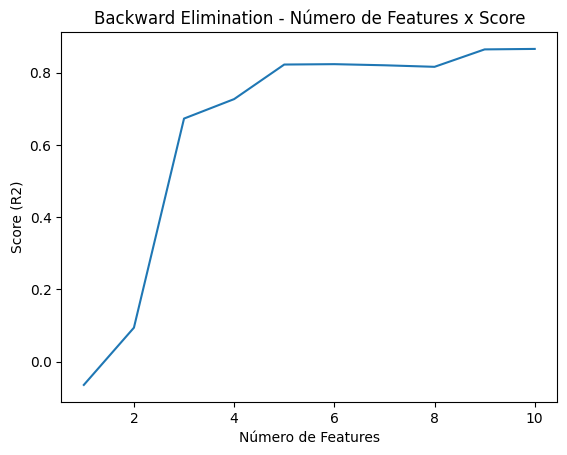

In [73]:
# Selecionar Features com Backward Elimination
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score 

max_features = 10

lista_scores = list()

for iFeatures in range(1, max_features + 1):
    modelo = LinearRegression()
    rfe = RFE(modelo, n_features_to_select=iFeatures, step=1)
    rfe = rfe.fit(x_treino_sc, y_treino)

    mask = rfe.support_

    selected_features = x_teste_sc.columns[mask]


    x_selected_treino = x_treino_sc[selected_features]

    score = cross_val_score(modelo, x_selected_treino, y_treino, cv=10, scoring='r2')

    print(f'Número de Features: {iFeatures} - Score: {np.mean(score)}')

    lista_scores.append(np.mean(score))

# Plotar gráfico de número de features x score
plt.plot(range(1, max_features + 1), lista_scores)
plt.xlabel('Número de Features')
plt.ylabel('Score (R2)')
plt.title('Backward Elimination - Número de Features x Score')
plt.show()



In [74]:
# validação cruzada
# usar o DataFrame com as features selecionadas (x_selected_treino) em vez do Index selected_features
modelo_Linear = LinearRegression()
X = x_selected_treino  # já padronizado e contém as features selecionadas
scores = cross_val_score(modelo_Linear, X, y_treino, cv=10, scoring='r2')

print("Scores de cada iteração: ", scores)

# Média dos scores
print("Média dos scores: ", np.mean(scores))

Scores de cada iteração:  [0.78064244 0.9335309  0.83454108 0.84772774 0.95279214 0.81774314
 0.94244108 0.6572433  0.98168204 0.90719217]
Média dos scores:  0.8655536026350656


In [83]:
# modelo final - Regressão Linear Multipla
# Treinar apenas com as features selecionadas
modelo_Linear.fit(x_treino_sc[selected_features], y_treino)
coef = modelo_Linear.coef_

print("Coeficientes: ", coef)
print("Media do Coeficientes: ", np.mean(coef))

# Construir DataFrame com nomes das features e seus coeficientes
features = pd.DataFrame({
	'Feature': selected_features,
	'Coefficient': coef
})

print("features: ", features)





Coeficientes:  [-3.48320174e+04  3.48360344e+04  6.23485877e+04 -6.23356138e+04
 -1.60865847e+04  1.60746797e+04  2.52778047e+04 -2.52600932e+04
 -5.26898795e+00 -2.82718382e+01]
Media do Coeficientes:  -1.0743428317152393
features:       Feature   Coefficient
0   NDVI_d28 -34832.017443
1   SAVI_d28  34836.034415
2   NDVI_d01  62348.587727
3   SAVI_d01 -62335.613801
4   NDVI_d04 -16086.584728
5   SAVI_d04  16074.679720
6   NDVI_d08  25277.804687
7   SAVI_d08 -25260.093179
8  GNDVI_d08     -5.268988
9     SR_d08    -28.271838


In [81]:
# testar usando lasso   
from sklearn.linear_model import Lasso
modelo_Lasso = Lasso(alpha=0.1) # valor de alpha pode ser ajustado      
modelo_Lasso.fit(x_treino_sc[selected_features], y_treino)
coef_lasso = modelo_Lasso.coef_
print("Coeficientes Lasso: ", coef_lasso)
features_lasso = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': coef_lasso
})

print(np.mean(coef_lasso))

Coeficientes Lasso:  [ 4.67809278e+00  4.15122125e-03  9.24751292e+00  0.00000000e+00
 -8.54755566e+00 -1.23544086e-02  1.01961118e+01  0.00000000e+00
 -1.83874710e+00 -2.52281991e+01]
-1.1500987491182006


In [82]:
# Testar usando Ridge
from sklearn.linear_model import Ridge  
modelo_Ridge = Ridge(alpha=1.0) # valor de alpha pode ser ajustado
modelo_Ridge.fit(x_treino_sc[selected_features], y_treino)
coef_ridge = modelo_Ridge.coef_
print("Coeficientes Ridge: ", coef_ridge)
features_ridge = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': coef_ridge
})
print(np.mean(coef_ridge))

Coeficientes Ridge:  [  2.47308415   2.47527481   4.91988896   4.91202037  -4.51510798
  -4.51762837   4.169019     4.15766221  -3.11875073 -22.01979503]
-1.1064332623542394


In [77]:
# testar nos dados de teste
X_test = x_teste_sc[selected_features]
y_pred = modelo_Linear.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_teste, y_pred)
r2 = r2_score(y_teste, y_pred)
print("MSE: ", mse)
print("R2: ", r2)

MSE:  56.84369944453087
R2:  0.8876342778702604
